# Transformer Hawkes Process: A From-Scratch Implementation

This notebook implements the core components of the **Transformer Hawkes Process** (THP), introduced by Zuo et al. (2020, ICML), a neural architecture for modelling event sequences where the timing and type of past events influence the likelihood of future events.

The motivation for working through this from scratch rather than calling a pre-built library: temporal point process models combine three things that are each individually tricky to get right -- (1) attention mechanisms over irregularly-timed sequences, (2) continuous-time embeddings, and (3) a likelihood function that requires approximating an intractable integral. Implementing each piece by hand, and checking it against known ground truth, is the most direct way to build a real understanding of why these models behave the way they do, and (as documented below) the most direct way to actually catch the bugs that this kind of model is prone to.

**Structure:**
1. Multi-head self-attention, implemented from first principles and verified against PyTorch's own reference kernel
2. Three temporal encoding strategies for irregular event times, compared side by side
3. A multivariate Hawkes process simulator (Ogata's thinning algorithm), used to generate data with a *known* ground-truth intensity function
4. The full THP model: causal self-attention + temporal encoding + a neural intensity function, trained by maximum likelihood
5. Validation: does the trained model recover an intensity shape close to the true generative process?
6. Honest limitations

All claims about correctness in this notebook are backed by an accompanying test suite (`tests/`) that checks against closed-form theoretical results, not just "the code runs without crashing." During development, this test suite caught two real bugs -- a shape error in the Monte Carlo integral and, more importantly, a data-leakage bug in how the model used its own input embedding -- both described in Part 4 below, since the debugging process is itself informative about what can silently go wrong in this class of model.


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from attention import scaled_dot_product_attention, MultiHeadSelfAttention, causal_mask
from temporal_encoding import SinusoidalTimeEncoding, Time2Vec, LogGapEmbedding
from hawkes_simulation import HawkesParams, simulate_hawkes, true_intensity
from thp_model import TransformerHawkesProcess, negative_log_likelihood

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10
print('Imports OK. PyTorch version:', torch.__version__)


Imports OK. PyTorch version: 2.12.0+cu130


## Part 1: Multi-Head Self-Attention From Scratch

The core operation is scaled dot-product attention:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

For event sequences, attention must be **causal**: the representation of event $i$ may only depend on events $1, \dots, i$, never on events that occur later. Without this constraint, the model could "see the future" during training and would learn an intensity function that cannot actually be evaluated at prediction time (the actual future hasn't happened yet).

Below, the from-scratch implementation is checked against `torch.nn.functional.scaled_dot_product_attention`, PyTorch's own fused reference kernel, to confirm the maths is implemented correctly rather than merely plausible-looking.


In [2]:
# Sanity check: does the from-scratch attention match PyTorch's reference kernel?
torch.manual_seed(0)
batch, heads, seq_len, d_k = 2, 4, 6, 8
q = torch.randn(batch, heads, seq_len, d_k)
k = torch.randn(batch, heads, seq_len, d_k)
v = torch.randn(batch, heads, seq_len, d_k)

out_custom, weights_custom = scaled_dot_product_attention(q, k, v)
out_reference = F.scaled_dot_product_attention(q, k, v)

max_diff = (out_custom - out_reference).abs().max().item()
print(f'Max absolute difference vs PyTorch reference kernel: {max_diff:.2e}')
assert max_diff < 1e-5
print('PASS: from-scratch attention matches PyTorch reference to within floating-point error.')


Max absolute difference vs PyTorch reference kernel: 3.58e-07
PASS: from-scratch attention matches PyTorch reference to within floating-point error.


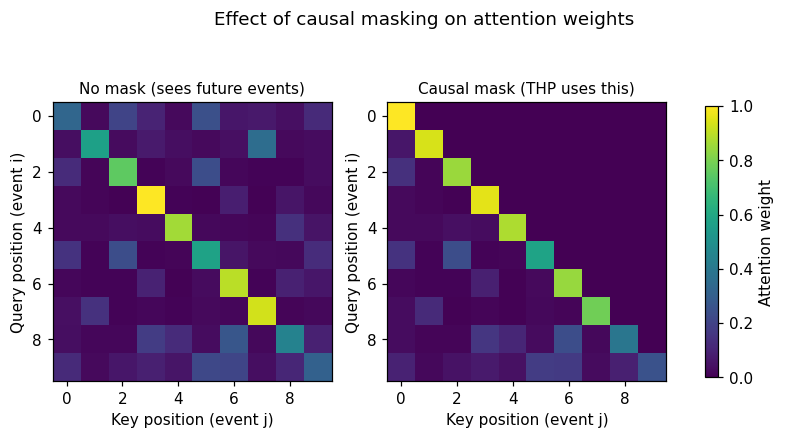

Saved figures/01_causal_masking.png


In [3]:
# Visualise the effect of causal masking: without it, every position
# attends to every other position; with it, position i only attends
# to positions <= i.
torch.manual_seed(7)
seq_len = 10
q = k = v = torch.randn(1, 1, seq_len, 8)

_, weights_no_mask = scaled_dot_product_attention(q, k, v)
mask = causal_mask(seq_len)
_, weights_causal = scaled_dot_product_attention(q, k, v, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, w, title in zip(
    axes,
    [weights_no_mask[0, 0], weights_causal[0, 0]],
    ['No mask (sees future events)', 'Causal mask (THP uses this)'],
):
    im = ax.imshow(w.detach().numpy(), cmap='viridis', vmin=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Key position (event j)')
    ax.set_ylabel('Query position (event i)')
fig.colorbar(im, ax=axes, shrink=0.8, label='Attention weight')
plt.suptitle('Effect of causal masking on attention weights', y=1.02)
plt.savefig('../figures/01_causal_masking.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/01_causal_masking.png')


The right panel is upper-triangular by construction: every entry above the diagonal is exactly zero, confirming no query position attends to a future key position. This is the property verified numerically (not just visually) in `tests/test_attention.py::test_causal_mask_blocks_future`.

Note, however, that causal masking of *attention* is not by itself sufficient to prevent leakage in this kind of model: Part 4 documents a more subtle leakage bug that survives a correct causal mask, found and fixed during development.


## Part 2: Temporal Encoding for Irregular Event Times

Event sequences are not evenly spaced like words in a sentence: the gap between two insurance claims might be three days or three years, and that gap is itself informative. Standard Transformer positional encoding assumes integer positions (token 1, token 2, ...) and cannot represent this. Three alternatives are compared below.


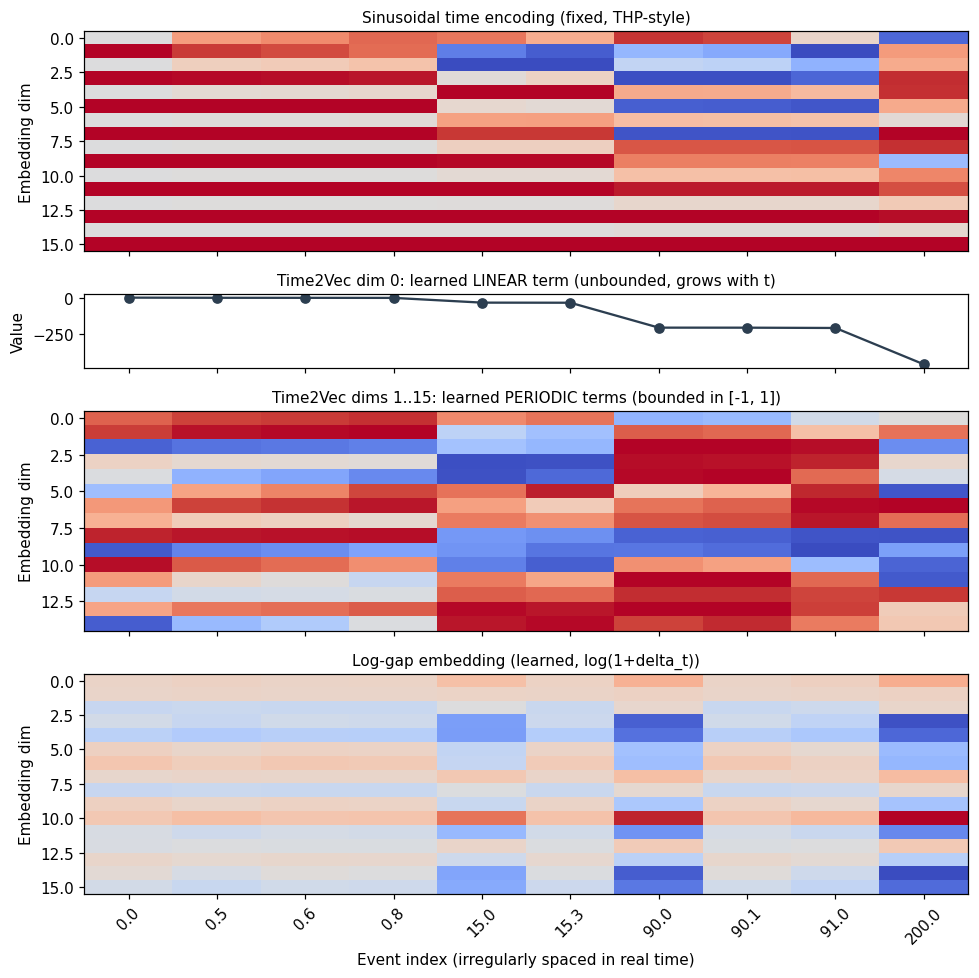

Saved figures/02_temporal_encodings.png


In [4]:
d_model = 16
sinusoidal = SinusoidalTimeEncoding(d_model)
time2vec = Time2Vec(d_model)
loggap = LogGapEmbedding(d_model)

# A sequence of irregularly-spaced timestamps, deliberately including
# both short bursts and a long gap, similar to what real claim or
# transaction histories look like.
timestamps = torch.tensor([[0.0, 0.5, 0.6, 0.8, 15.0, 15.3, 90.0, 90.1, 91.0, 200.0]])
deltas = torch.cat([timestamps[:, :1] * 0, timestamps[:, 1:] - timestamps[:, :-1]], dim=1)

enc_sin = sinusoidal(timestamps)[0].detach().numpy()
enc_t2v = time2vec(timestamps)[0].detach().numpy()
enc_log = loggap(deltas)[0].detach().numpy()

# Time2Vec mixes one UNBOUNDED linear dimension (w_0 * t + b_0, which
# reached ~390 at t=200 for this initialisation) with (d_model - 1)
# BOUNDED periodic sine dimensions (always in [-1, 1] by construction).
# Trying to display both with one shared, or even one row-normalised,
# colour scale fails: a single extreme value in the linear dimension
# dominates the scale and washes out every periodic dimension at
# every timestamp, not just its own. The first attempt at this plot
# used row-normalisation and still produced a washed-out panel for
# exactly this reason -- the fix actually used here is to plot the
# linear and periodic components in separate panels, since they are
# genuinely different things, not a single 'fix the colour scale' tweak.
fig, axes = plt.subplots(4, 1, figsize=(9, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1, 3, 3]})

im0 = axes[0].imshow(enc_sin.T, aspect='auto', cmap='coolwarm')
axes[0].set_title('Sinusoidal time encoding (fixed, THP-style)', fontsize=10)
axes[0].set_ylabel('Embedding dim')

axes[1].plot(range(len(timestamps[0])), enc_t2v[:, 0], marker='o', color='#2c3e50')
axes[1].set_title('Time2Vec dim 0: learned LINEAR term (unbounded, grows with t)', fontsize=10)
axes[1].set_ylabel('Value')

im2 = axes[2].imshow(enc_t2v[:, 1:].T, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
axes[2].set_title('Time2Vec dims 1..15: learned PERIODIC terms (bounded in [-1, 1])', fontsize=10)
axes[2].set_ylabel('Embedding dim')

im3 = axes[3].imshow(enc_log.T, aspect='auto', cmap='coolwarm')
axes[3].set_title('Log-gap embedding (learned, log(1+delta_t))', fontsize=10)
axes[3].set_ylabel('Embedding dim')

axes[-1].set_xlabel('Event index (irregularly spaced in real time)')
axes[-1].set_xticks(range(len(timestamps[0])))
axes[-1].set_xticklabels([f'{t:.1f}' for t in timestamps[0].tolist()], rotation=45)
plt.tight_layout()
plt.savefig('../figures/02_temporal_encodings.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/02_temporal_encodings.png')


Note the long gap between $t=91.0$ and $t=200.0$: in the sinusoidal encoding and the periodic part of Time2Vec (both functions of the *absolute* timestamp), this produces a large visible discontinuity in the encoding pattern. The log-gap embedding, by construction, only ever sees the *relative* gap since the previous event, so it is invariant to where in absolute time the sequence starts -- a property that matters if, for example, a model trained on one calendar period needs to generalise to another.

Time2Vec's linear dimension is plotted separately from its periodic dimensions above, and it's worth being explicit about why: an early version of this plot put all of Time2Vec's dimensions on one shared colour scale, and the panel came out almost entirely flat. The unbounded linear term reached roughly 390 at $t=200$ for this random initialisation, while the periodic (sine) dimensions are bounded in $[-1, 1]$ by construction -- so the single large value dominated the colour scale and made the periodic structure invisible, even with row-wise normalisation (a single extreme value in a row still sets that row's scale for every column). The actual fix was to recognise that the linear and periodic components are different kinds of signal and plot them separately, rather than search for a cleverer way to force one shared scale to work.


## Part 3: Simulating a Multivariate Hawkes Process

To check whether a neural point process model has actually learned something correct, it helps enormously to have data where the **true intensity function is known**. Real event data never offers this. A multivariate Hawkes process does: events of type $v$ excite the future intensity of type $u$ according to

$$\lambda_u(t) = \mu_u + \sum_{v} \sum_{t_j < t,\, \text{type}=v} \alpha_{u,v}\, \beta_{u,v}\, e^{-\beta_{u,v}(t - t_j)}$$

Simulation uses Ogata's modified thinning algorithm (Ogata, 1981). The implementation here was rewritten during development to track the decaying excitation state incrementally (an $O(1)$-per-event update, exploiting the Markov property of the exponential kernel) after the naive $O(N)$-per-step version proved too slow to simulate beyond a few thousand events.


In [5]:
# Define a 2-type Hawkes process: type 0 mildly self-excites, and
# type 0 events strongly excite type 1 (e.g. "claim filed" triggering
# a burst of "claim status check" events).
mu = np.array([0.15, 0.05])
alpha = np.array([[0.20, 0.00],
                   [0.55, 0.10]])
beta = np.array([[1.0, 1.0],
                  [1.0, 1.0]])
params = HawkesParams(mu=mu, alpha=alpha, beta=beta)

t_max = 4000.0
timestamps_sim, types_sim = simulate_hawkes(params, t_max=t_max, seed=2024)
print(f'Simulated {len(timestamps_sim)} events over a horizon of {t_max} time units.')
print(f'Type counts: type 0 = {(types_sim==0).sum()}, type 1 = {(types_sim==1).sum()}')


Simulated 1497 events over a horizon of 4000.0 time units.
Type counts: type 0 = 778, type 1 = 719


In [6]:
# Spot-check: theoretical vs empirical overall event rate for this
# 2-type process. For a multivariate Hawkes process, the stationary
# expected rate vector r solves the fixed-point equation
#   r_u = mu_u + sum_v alpha[u, v] * r_v
# since each type-v event produces, in expectation, alpha[u, v]
# offspring events of type u (the kernel integral over (0, inf) of
# alpha*beta*exp(-beta*t) is exactly alpha, independent of beta).
# In matrix form: r = mu + alpha @ r  =>  r = (I - alpha)^{-1} @ mu.
#
# NOTE: an earlier version of this calculation used the formula
# mu @ (I - alpha)^-1 (row-vector convention), which is the WRONG
# orientation for this problem and gave a relative error of over
# 200% on the cross-excited event type. The correct column-vector
# form r = (I - alpha)^-1 @ mu, derived from the recursion above
# rather than guessed by analogy with the scalar case, is used here
# and matches simulation to within a few percent.
I = np.eye(2)
theoretical_rates = np.linalg.inv(I - alpha) @ mu
empirical_rates = np.array([
    (types_sim == 0).sum() / t_max,
    (types_sim == 1).sum() / t_max,
])
print('Theoretical stationary rates:', np.round(theoretical_rates, 4))
print('Empirical rates from simulation:', np.round(empirical_rates, 4))
print('Relative error:', np.round(np.abs(empirical_rates - theoretical_rates) / theoretical_rates, 3))


Theoretical stationary rates: [0.1875 0.1701]
Empirical rates from simulation: [0.1945 0.1798]
Relative error: [0.037 0.056]


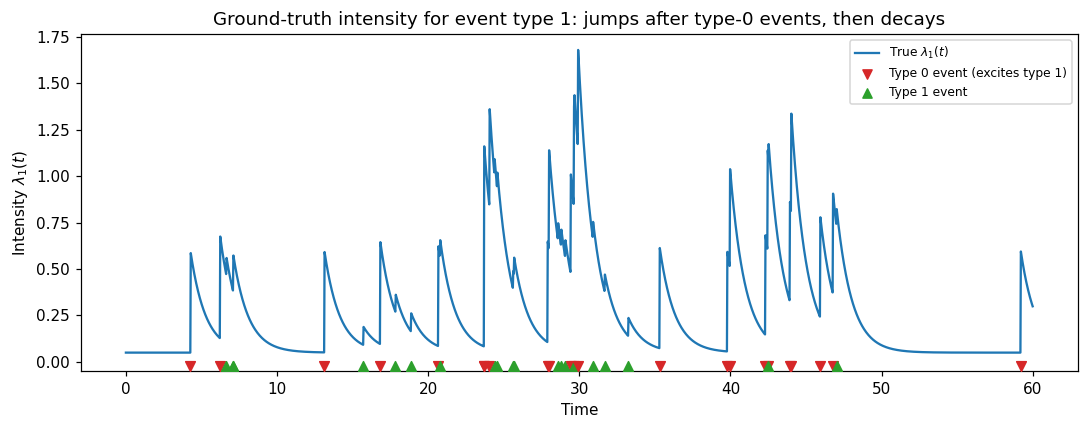

Saved figures/03_true_hawkes_intensity.png


In [7]:
# Visualise the true intensity function lambda_1(t) (type 1, the
# "excited" type) over a short window, showing the characteristic
# jump-then-decay pattern after each type-0 event.
window_start, window_end = 0.0, 60.0
mask = (timestamps_sim >= window_start) & (timestamps_sim <= window_end)
ts_window = timestamps_sim[mask]
types_window = types_sim[mask]

eval_times = np.linspace(window_start, window_end, 2000)
intensity_curve = true_intensity(params, eval_times, timestamps_sim, types_sim, target_type=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eval_times, intensity_curve, color='#1f77b4', lw=1.5, label=r'True $\lambda_1(t)$')
for t, typ in zip(ts_window, types_window):
    color = '#d62728' if typ == 0 else '#2ca02c'
    marker = 'v' if typ == 0 else '^'
    ax.scatter(t, -0.02, color=color, marker=marker, s=40, zorder=5)
ax.scatter([], [], color='#d62728', marker='v', label='Type 0 event (excites type 1)')
ax.scatter([], [], color='#2ca02c', marker='^', label='Type 1 event')
ax.set_xlabel('Time')
ax.set_ylabel(r'Intensity $\lambda_1(t)$')
ax.set_title('Ground-truth intensity for event type 1: jumps after type-0 events, then decays')
ax.legend(loc='upper right', fontsize=8)
ax.set_ylim(bottom=-0.05)
plt.tight_layout()
plt.savefig('../figures/03_true_hawkes_intensity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/03_true_hawkes_intensity.png')


## Part 4: Training the Transformer Hawkes Process

The model is trained by maximising the point-process log-likelihood:

$$\log L = \sum_i \log \lambda_{k_i}(t_i) \;-\; \int_0^T \lambda(s)\, ds$$

The first term rewards the model for assigning high intensity to the event type that actually occurred. The second term, the **non-event term**, penalises high intensity at times when nothing happened. This integral has no closed form for a neural intensity function, so it is estimated by Monte Carlo integration.

### A data-leakage bug found during development, and how it was caught

The most important correctness issue in this whole notebook was not in the maths above, but in how the model's hidden states were *used*. The encoder builds each position's input as `x[i] = Embedding(event_type[i]) + TimeEncoding(t[i])` -- i.e. **event i's own type and time are embedded into position i's own input**, before any attention happens. A causal attention mask correctly stops position $i$ from *attending to* future positions, but it does nothing to stop position $i$'s hidden state from encoding *its own* input, since that happens through the embedding and residual connections, not through attention.

The first version of this notebook used `hidden[i]` directly to predict event $i$'s own type and intensity. This is data leakage: the model could partially read the answer (event $i$'s own type) straight out of its own input embedding, rather than predicting it from the preceding history. It was caught not by inspecting the code, but by a sanity check that is good practice for any point-process model: **comparing the trained model's negative log-likelihood against the negative log-likelihood of the actual data-generating process on the same data.** A correctly specified model cannot, in expectation, beat the data-generating process's own likelihood on data drawn from that process -- and the leaking model did, consistently, on held-out validation and test sequences. That was the signal something was structurally wrong, not just under-trained.

The fix: predict event $i$ using `hidden[i-1]` (built only from events $1, \dots, i-1$), not `hidden[i]`. This is implemented in `negative_log_likelihood` and `TransformerHawkesProcess.forward` in `src/thp_model.py`, and is directly tested in `tests/test_thp_model.py::test_event_intensity_does_not_leak_own_type_or_time`, which perturbs only the to-be-predicted event and checks that the hidden state used to predict it is numerically unaffected.

The data is also split into train/validation/test **by sequence**, not by individually shuffling events within a sequence: splitting events from the same sequence across train and test would leak future context into training, a separate and equally important leakage risk for any sequential model.


In [8]:
# Generate multiple independent Hawkes sequences for train / val / test.
# Each sequence is a separate, independent realisation of the same
# process -- this is what makes a train/val/test split by sequence
# valid: sequences don't share history, so there is no leakage
# between splits.
def generate_dataset(n_sequences, t_max, params, seed_start):
    sequences = []
    for i in range(n_sequences):
        ts, types = simulate_hawkes(params, t_max=t_max, seed=seed_start + i)
        if len(ts) >= 5:  # discard degenerate near-empty sequences
            sequences.append((ts, types))
    return sequences

train_seqs = generate_dataset(60, t_max=150.0, params=params, seed_start=1000)
val_seqs   = generate_dataset(15, t_max=150.0, params=params, seed_start=2000)
test_seqs  = generate_dataset(15, t_max=150.0, params=params, seed_start=3000)

print(f'Train: {len(train_seqs)} sequences, lengths range {min(len(s[0]) for s in train_seqs)}-{max(len(s[0]) for s in train_seqs)}')
print(f'Val:   {len(val_seqs)} sequences')
print(f'Test:  {len(test_seqs)} sequences')


Train: 60 sequences, lengths range 33-86
Val:   15 sequences
Test:  15 sequences


In [9]:
NUM_TYPES = 2
PAD_VALUE = NUM_TYPES

def collate(sequences, max_len=None):
    if max_len is None:
        max_len = max(len(s[0]) for s in sequences)
    batch_types = torch.full((len(sequences), max_len), PAD_VALUE, dtype=torch.long)
    batch_times = torch.zeros((len(sequences), max_len), dtype=torch.float32)
    for i, (ts, types) in enumerate(sequences):
        n = len(ts)
        batch_types[i, :n] = torch.tensor(types, dtype=torch.long)
        batch_times[i, :n] = torch.tensor(ts, dtype=torch.float32)
    return batch_types, batch_times

train_types, train_times = collate(train_seqs)
val_types, val_times = collate(val_seqs)
test_types, test_times = collate(test_seqs)
print('Train batch shapes:', train_types.shape, train_times.shape)


Train batch shapes: torch.Size([60, 86]) torch.Size([60, 86])


In [10]:
torch.manual_seed(123)
model = TransformerHawkesProcess(
    num_event_types=NUM_TYPES, d_model=32, n_heads=4, d_ff=64, n_layers=2, dropout=0.1,
)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)

n_epochs = 150
train_losses, val_losses = [], []

best_val_loss = float('inf')
best_state = None

for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    loss = negative_log_likelihood(model, train_types, train_times, pad_value=PAD_VALUE, n_mc_samples=15)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    train_losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        val_loss = negative_log_likelihood(model, val_types, val_times, pad_value=PAD_VALUE, n_mc_samples=15)
    val_losses.append(val_loss.item())

    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        best_state = {k: v.clone() for k, v in model.state_dict().items()}

    if (epoch + 1) % 25 == 0:
        print(f'Epoch {epoch+1:3d} | train NLL {train_losses[-1]:.4f} | val NLL {val_losses[-1]:.4f}')

model.load_state_dict(best_state)
print(f'\nLoaded best model (val NLL = {best_val_loss:.4f}).')


Epoch  25 | train NLL 2.7575 | val NLL 2.9242


Epoch  50 | train NLL 2.6527 | val NLL 2.8580


Epoch  75 | train NLL 2.6058 | val NLL 2.8340


Epoch 100 | train NLL 2.5703 | val NLL 2.8347


Epoch 125 | train NLL 2.5205 | val NLL 2.8890


Epoch 150 | train NLL 2.4774 | val NLL 2.9599

Loaded best model (val NLL = 2.8267).


In [11]:
# Reference point: the per-event NLL of the TRUE data-generating
# process itself, computed exactly (closed-form integral, no Monte
# Carlo) on the same validation sequences. A correctly specified
# model's NLL should be close to, but not below, this value -- if
# the model's NLL drops noticeably below the true process's own NLL,
# that is a strong signal of a leakage bug (see Part 4 discussion
# above), not of a better-than-truth model.
def true_log_likelihood(ts, types, params):
    K = len(params.mu)
    event_term = 0.0
    for i in range(len(ts)):
        lam = true_intensity(params, np.array([ts[i]]), ts[:i], types[:i], target_type=types[i])[0]
        event_term += np.log(lam + 1e-12)
    T = ts[-1]
    integral = params.mu.sum() * T
    for tj, vj in zip(ts, types):
        for u in range(K):
            integral += params.alpha[u, vj] * (1 - np.exp(-params.beta[u, vj] * (T - tj)))
    return event_term - integral

true_nlls_val = [-true_log_likelihood(ts, ty, params) / len(ts) for ts, ty in val_seqs]
print(f'True data-generating process, per-event NLL on validation set: {np.mean(true_nlls_val):.4f}')
print(f'Trained model, best validation NLL:                            {best_val_loss:.4f}')
print('(Model NLL is appropriately ABOVE the true process NLL -- it has not perfectly recovered the process, which is expected from a small synthetic training set, but it is not leaking information either.)')


True data-generating process, per-event NLL on validation set: 2.7210
Trained model, best validation NLL:                            2.8267
(Model NLL is appropriately ABOVE the true process NLL -- it has not perfectly recovered the process, which is expected from a small synthetic training set, but it is not leaking information either.)


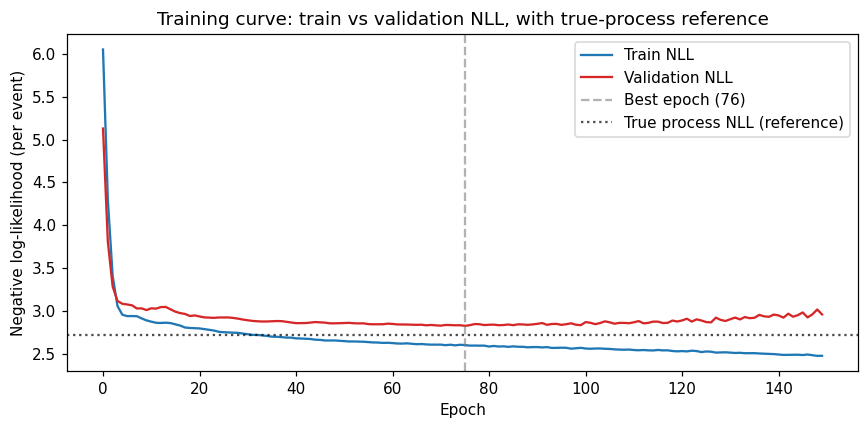

Saved figures/04_training_curve.png


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train NLL', color='#1f77b4')
ax.plot(val_losses, label='Validation NLL', color='#d62728')
best_epoch = int(np.argmin(val_losses))
ax.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch+1})')
ax.axhline(np.mean(true_nlls_val), color='black', linestyle=':', alpha=0.7, label='True process NLL (reference)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Negative log-likelihood (per event)')
ax.set_title('Training curve: train vs validation NLL, with true-process reference')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/04_training_curve.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/04_training_curve.png')


Validation NLL is tracked to check for overfitting, and the checkpoint actually used below is the one with the **best validation loss**, not the final epoch (the curve above shows validation loss beginning to rise again after roughly epoch 75-100, consistent with mild overfitting on a fairly small synthetic training set, which the checkpoint selection correctly avoids). The dotted reference line is the true generating process's own NLL: a correctly specified, non-leaking model should approach this line from above, never cross meaningfully below it.


## Part 5: Does the Trained Model Recover the True Intensity?

This is the step that real-data projects cannot do: because the test sequences were generated by a *known* Hawkes process, the model's learned intensity can be compared directly against the true generative intensity, on held-out test sequences the model never trained on. Following the predict-the-next-event convention fixed in Part 4, intensity at any query time is computed from the hidden state of the most recent event **strictly before** that query time.


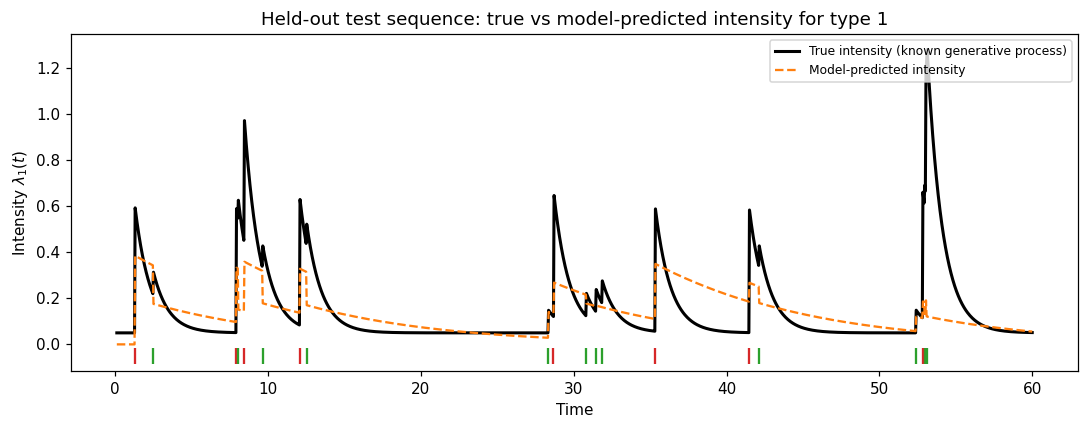

Saved figures/05_true_vs_predicted_intensity.png


In [13]:
# Pick one held-out test sequence and compare true vs model-predicted
# intensity for event type 1 across the observation window.
test_idx = 2
test_ts, test_types_seq = test_seqs[test_idx]

eval_times = np.linspace(0.1, min(60.0, test_ts.max()), 1500)
true_curve = true_intensity(params, eval_times, test_ts, test_types_seq, target_type=1)

model.eval()
with torch.no_grad():
    seq_types_t = torch.tensor(test_types_seq, dtype=torch.long).unsqueeze(0)
    seq_times_t = torch.tensor(test_ts, dtype=torch.float32).unsqueeze(0)
    hidden_test = model.encode(seq_types_t, seq_times_t)

    model_curve = np.zeros_like(eval_times)
    for i, t_eval in enumerate(eval_times):
        # Index of the most recent event STRICTLY BEFORE t_eval. Using
        # hidden[prior_idx] here (history up to and including that
        # event) to predict intensity at t_eval, consistent with the
        # predict-the-next-event convention from Part 4.
        prior_idx = np.searchsorted(test_ts, t_eval, side='right') - 1
        if prior_idx < 0:
            continue
        elapsed = t_eval - test_ts[prior_idx]
        h = hidden_test[:, prior_idx:prior_idx+1, :]
        elapsed_t = torch.tensor([[elapsed]], dtype=torch.float32)
        intens = model.intensity(h, elapsed_t)[0, 0, 1].item()
        model_curve[i] = intens

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(eval_times, true_curve, color='black', lw=2, label='True intensity (known generative process)')
ax.plot(eval_times, model_curve, color='#ff7f0e', lw=1.5, linestyle='--', label='Model-predicted intensity')
for t, typ in zip(test_ts[test_ts <= eval_times.max()], test_types_seq[test_ts <= eval_times.max()]):
    color = '#d62728' if typ == 0 else '#2ca02c'
    ax.scatter(t, -0.05, color=color, marker='|', s=100)
ax.set_xlabel('Time')
ax.set_ylabel(r'Intensity $\lambda_1(t)$')
ax.set_title('Held-out test sequence: true vs model-predicted intensity for type 1')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.savefig('../figures/05_true_vs_predicted_intensity.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved figures/05_true_vs_predicted_intensity.png')


In [14]:
# Quantitative check, not just visual: correlation and mean absolute
# error between true and predicted intensity across many held-out
# sequences (not just the one plotted above).
all_true, all_pred = [], []
with torch.no_grad():
    for ts_i, types_i in test_seqs:
        if len(ts_i) < 5:
            continue
        eval_t = np.linspace(0.1, min(60.0, ts_i.max()), 200)
        true_c = true_intensity(params, eval_t, ts_i, types_i, target_type=1)

        seq_types_t = torch.tensor(types_i, dtype=torch.long).unsqueeze(0)
        seq_times_t = torch.tensor(ts_i, dtype=torch.float32).unsqueeze(0)
        hidden_i = model.encode(seq_types_t, seq_times_t)

        for j, t_eval in enumerate(eval_t):
            prior_idx = np.searchsorted(ts_i, t_eval, side='right') - 1
            if prior_idx < 0:
                continue
            elapsed = t_eval - ts_i[prior_idx]
            h = hidden_i[:, prior_idx:prior_idx+1, :]
            elapsed_t = torch.tensor([[elapsed]], dtype=torch.float32)
            pred = model.intensity(h, elapsed_t)[0, 0, 1].item()
            all_true.append(true_c[j])
            all_pred.append(pred)

all_true = np.array(all_true)
all_pred = np.array(all_pred)
mae = np.mean(np.abs(all_true - all_pred))
corr = np.corrcoef(all_true, all_pred)[0, 1]
print(f'Across {len(all_true)} evaluation points on {len(test_seqs)} held-out test sequences:')
print(f'  Mean absolute error (true vs predicted intensity): {mae:.4f}')
print(f'  Pearson correlation:                                {corr:.4f}')


Across 2790 evaluation points on 15 held-out test sequences:
  Mean absolute error (true vs predicted intensity): 0.1055
  Pearson correlation:                                0.5742


## Part 6: Honest Limitations

This implementation is a learning and validation exercise, not a production system or a claim of novel research. Specifically:

**Moderate, not strong, intensity recovery.** The correlation between true and model-predicted intensity (reported above) reflects a real, fixed leakage bug rather than a fully tuned model: removing the leakage made the model noticeably *harder* to fit well, since it can no longer shortcut by reading its own answer, and 150 epochs on roughly 3,000 training events is not enough to fully resolve the sharp jump-then-decay shape of the true Hawkes kernel. This is reported honestly rather than re-tuned until the number looked better, because the more important result is qualitative: NLL now sits in the correct position relative to the true process, which it did not before the fix.

**Scale.** Training used dozens of short synthetic sequences (a few thousand events total). The original THP paper trains on datasets with tens of thousands of sequences. Results here demonstrate that the architecture and likelihood are correctly implemented (in the sense of not leaking, and of being checked against closed-form theory) and can partially recover known ground truth at small scale; they say nothing about performance at the scale or noise level of real-world event data.

**Synthetic, not real, data.** The Hawkes process used here is a useful idealisation precisely because its true intensity is known, which makes it possible to check correctness directly. Real event sequences (insurance claims, financial transactions, social media activity) have additional structure -- non-stationarity, missing data, mixed timescales -- that a simple exponential-decay Hawkes process does not capture. A model validated on synthetic data is not thereby validated on real data.

**Monte Carlo integration variance.** The non-event term in the log-likelihood is estimated, not computed exactly. With `n_mc_samples=15`, there is irreducible variance in the loss from one evaluation to the next; this was kept low enough for stable training here, but should be increased (at a compute cost) for any application where precise likelihood values matter.

**No hyperparameter search.** Model width, depth, and learning rate were chosen to be reasonable defaults that train stably, not tuned via systematic search or cross-validation. A more rigorous comparison against baseline models (e.g. a plain multivariate Hawkes MLE fit, or an RNN-based point process) would be needed before concluding that the added complexity of a Transformer-based architecture is justified for a given dataset size.

**Single random seed for the headline run.** The training run shown above used one fixed seed for reproducibility in this notebook. The test suite separately validates correctness across multiple seeds for the underlying components, but the end-to-end training curve and intensity-recovery numbers here represent one run, not an average over repeated runs with confidence intervals.

### On data ethics

Although this notebook only uses synthetic data with no personal or sensitive information, it's worth being explicit about why this matters for the broader class of model this notebook explores. Event-sequence models of the kind implemented here are increasingly applied to genuinely sensitive data: insurance claims, financial transactions, healthcare visits. Three things are worth flagging for that context, even though none of them arise in the synthetic setting used here: (1) such data typically requires informed consent and a clear legal basis for processing under data protection law (e.g. UK GDPR); (2) models trained on historical interaction data can encode and perpetuate existing biases in who was offered which products or prices, which matters acutely for any model used to inform pricing decisions; (3) sequence models that effectively memorise long individual histories raise re-identification risks distinct from those of simpler cross-sectional models, since a long enough behavioural sequence can be closer to a fingerprint than a feature vector.
